<a href="https://colab.research.google.com/github/Kmjng/BodyFat-Predict/blob/main/%5B%EB%B6%84%EB%A5%98_3%5DXGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 13.4 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import RobustScaler # 연속형 변수 스케일링 (중앙값(median)과 IQR(Interquartile Range, 1사분위수와 3사분위수의 차이)을 사용하여 스케일링)
from sklearn.model_selection import train_test_split, GridSearchCV # 교차검증 (홀드 아웃)
from sklearn.metrics import accuracy_score, f1_score,classification_report # 평가지표
import numpy as np
from imblearn.over_sampling import SMOTE # 클래스 불균형 - 데이터 증강

# 시각화 도구
from sklearn.inspection import permutation_importance # 중요변수 시각화 기법 (확인, 비교)
import shap # !pip install shap # 중요변수 시각화 기법 (Shapley Additive exPlanations)
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# 데이터 불러오기 (이전에 이상치 처리 완 - EDA 생략)
df_f = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/중간프로젝트/Dataset.csv", encoding='CP949')
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  177 non-null    int64  
 1   BodyFat     177 non-null    float64
 2   Original    177 non-null    object 
 3   Sex         177 non-null    object 
 4   Age         177 non-null    int64  
 5   Weight      177 non-null    float64
 6   Height      177 non-null    float64
 7   Neck        177 non-null    float64
 8   Chest       177 non-null    float64
 9   Abdomen     177 non-null    float64
 10  Hip         177 non-null    float64
 11  Thigh       177 non-null    float64
 12  Knee        177 non-null    float64
 13  Ankle       177 non-null    float64
 14  Biceps      177 non-null    float64
 15  Forearm     177 non-null    float64
 16  Wrist       177 non-null    float64
 17  BMI         177 non-null    float64
 18  AC_ratio    177 non-null    float64
 19  HT_ratio    177 non-null    f

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_f = df_f[['Height','Weight','Chest','Abdomen','Hip','Thigh','Biceps','Ankle','Knee','Neck','Wrist','Class']]
X = df_f.drop('Class',axis = 1)
y = df_f['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
print(X_train.shape, X_test.shape)

(141, 11) (36, 11)


In [ ]:
# smote 기법을 이용 (# 주의: train set에 대해 적용)
# SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5, n_jobs=None)
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print("SMOTE 적용 전 학습용 피처/레이블 데이터 세트 : ", X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트 :', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 값의 분포 :\n',y_train_over.value_counts() )
'''
 Class
1    126
0    126
'''
X_prime = X_train_over # 증강된 데이터
y_prime = y_train_over


SMOTE 적용 전 학습용 피처/레이블 데이터 세트 :  (141, 11) (141,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트 : (252, 11) (252,)
SMOTE 적용 후 값의 분포 :
 Class
0    126
1    126
Name: count, dtype: int64


In [ ]:
# train, test set에 대해 스케일링
scaler = RobustScaler()
X_prime = scaler.fit_transform(X_prime)
X_test_prime = scaler.transform(X_test) # array 로 리턴됨
X_prime = pd.DataFrame(data= X_prime, columns = X_train_over.columns)
X_test_prime = pd.DataFrame(data= X_test_prime, columns = X_test.columns)


In [ ]:
# grid search cv를 통한 파라미터 최적화
param_grid = {

          'max_depth':[1, 3, 5],
          'min_child_weight':[1, 3, 5],
          'n_estimators' : [100, 200],
          'colsample_bytree':[0.5, 0.7],
          'learning_rate':[0.01, 0.1]
}

# XGBClassifier 모델 생성
model = XGBClassifier()

# GridSearchCV를 사용하여 모델과 하이퍼파라미터 그리드 정의
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy') # 기준: accuracy

# 그리드 서치를 사용하여 모델 학습
grid_search.fit(X_prime, y_prime)
best_model = grid_search.best_estimator_ # 파라미터를 모델에 적용
# 최적 하이퍼파라미터 출력
print("Best Hyperparameters:", grid_search.best_params_, "/최적 성능:", grid_search.best_score_)


Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100} /최적 성능: 0.9605490196078431


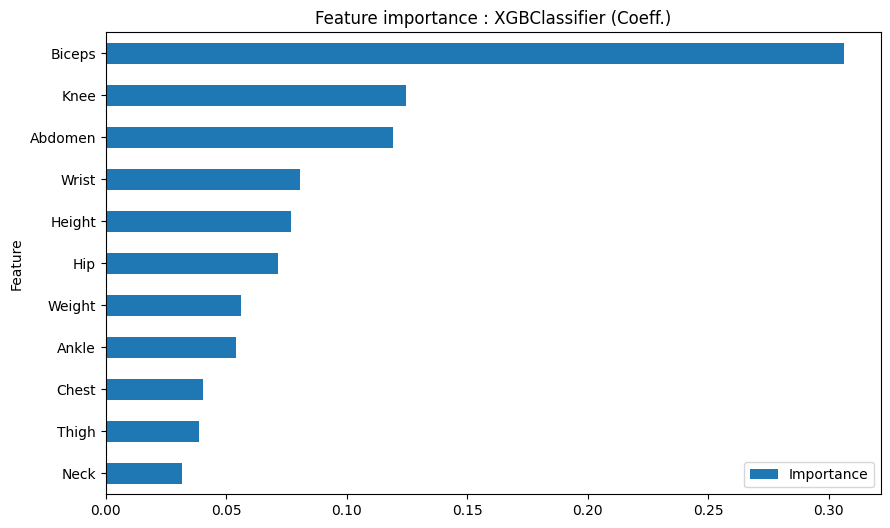

In [ ]:
# feature importance
feature_importance = pd.DataFrame({'Feature': X_train_over.columns, 'Importance': best_model.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
plt.title('Feature importance : XGBClassifier (Coeff.)')
plt.show()

#(AttributeError: Coefficients are not defined for Booster type None)

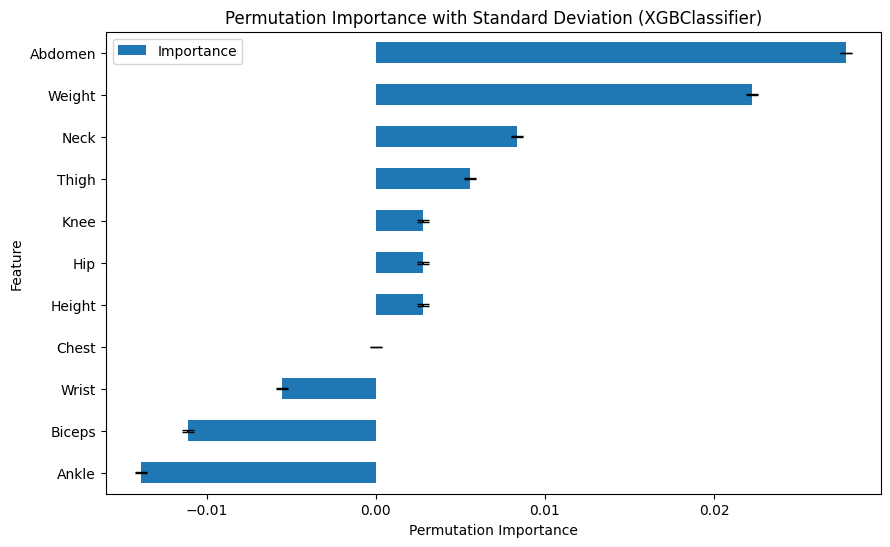

In [ ]:
# permutation_importance (test set에 대해 기여도 시각화)

result = permutation_importance(best_model, X_test_prime, y_test, n_repeats=10, random_state=40)

per_imp_df = pd.DataFrame({'Feature': X.columns,'Importance': result.importances_mean,
                           'Standard Deviation': result.importances_std})
per_imp_df = per_imp_df.sort_values('Importance', ascending=True)

ax = per_imp_df.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6), yerr='Standard Deviation', capsize=4)
ax.set_xlabel('Permutation Importance')
ax.set_title('Permutation Importance with Standard Deviation (XGBClassifier)')
plt.show()


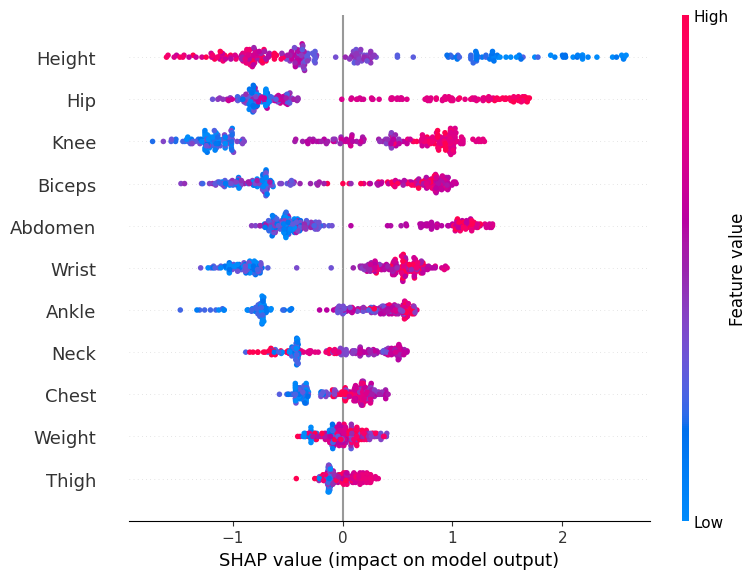

In [ ]:
# SHAP summary plot

explainer = shap.Explainer(best_model, X_prime)
shap_values = explainer.shap_values(X_prime)

shap.summary_plot(shap_values, X_prime)
# SHAP 요약 플롯 생성

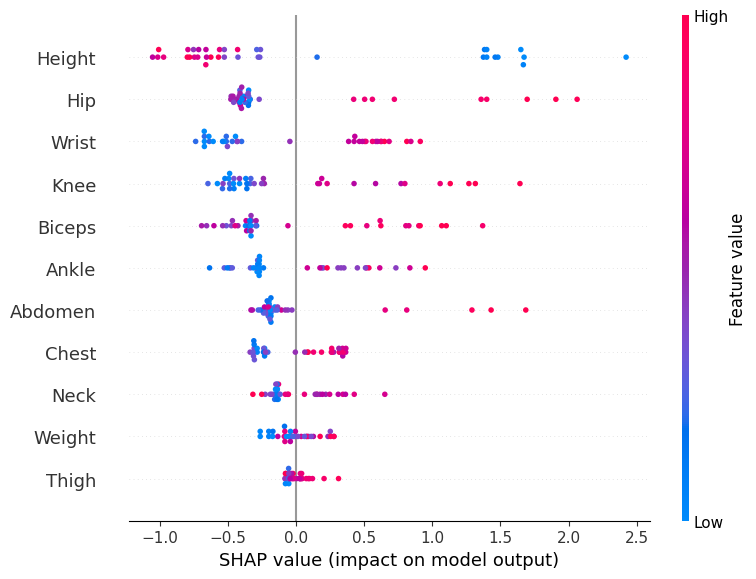

In [ ]:
# SHAP summary plot (for test set)

explainer = shap.Explainer(best_model, X_test_prime)
shap_values = explainer.shap_values(X_test_prime)

shap.summary_plot(shap_values, X_test_prime)
# SHAP 요약 플롯 생성
# (변경사항: XGBoost 모델링은 train과 test에 대해 중요변수가 다르게 나타남)

In [ ]:

X_prime_SHAP = X_prime[['Height','Hip','Knee','Biceps','Abdomen','Wrist']]
X_test_SHAP = X_test_prime[['Height','Hip','Knee','Biceps','Abdomen','Wrist']]


In [ ]:

"""# SHAP 변수 토대로 다시 모델링"""

# XGBClassifier 모델 생성
model = XGBClassifier()

# grid search cv를 통한 파라미터 최적화
param_grid = {

          'max_depth':[1, 3, 5],
          'min_child_weight':[1, 3, 5],
          'n_estimators' : [100, 200],
          'colsample_bytree':[0.5, 0.7],
          'learning_rate':[0.01, 0.1]
}


# GridSearchCV를 사용하여 모델과 하이퍼파라미터 그리드 정의
grid_search2 = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# 그리드 서치를 사용하여 모델 학습
grid_search2.fit(X_prime_SHAP, y_prime)
best_model2 = grid_search2.best_estimator_ # 파라미터 적용

# 최적의 하이퍼파라미터 출력
print("Best Hyperparameters:", grid_search2.best_params_)
print("최적의 성능:", grid_search2.best_score_)




Best Hyperparameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100}
최적의 성능: 0.9526274509803923


In [ ]:

# 트레인 데이터로 예측
X_prime_SHAP.columns
y_pre = best_model2.predict(X_prime_SHAP)

# 정확도 출력
print("train Accuracy:", accuracy_score(y_prime, y_pre))

# F1 score 출력
print("train F1 Score:", f1_score(y_prime, y_pre, average='weighted'))


train Accuracy: 0.9841269841269841
train F1 Score: 0.9841269841269841


In [ ]:

# 테스트 데이터로 예측
y_pred = best_model2.predict(X_test_SHAP)

# 정확도 출력
print("Accuracy:", accuracy_score(y_test, y_pred))

# F1 score 출력
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# 분류 보고서 출력
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8611111111111112
F1 Score: 0.8662858089087597
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        31
           1       0.50      0.60      0.55         5

    accuracy                           0.86        36
   macro avg       0.72      0.75      0.73        36
weighted avg       0.87      0.86      0.87        36

